In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("./Data/exam.txt", header=None)
df.head()

,0,1,2
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


In [3]:
df.columns = ["t1","t2","target"]
df.head()

,t1,t2,target
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


In [4]:
##making it
#t0^a +t2^b+t1^c*t2^d

In [5]:
powers = []
for i in range(0,7):
    for j in range(0,7):
        for k in range(0,7):
            for l in range(0,7):
                if (i+j+k+l <= 6):
                    powers.append((i,j,k,l))
powers

[(0, 0, 0, 0),
 (0, 0, 0, 1),
 (0, 0, 0, 2),
 (0, 0, 0, 3),
 (0, 0, 0, 4),
 (0, 0, 0, 5),
 (0, 0, 0, 6),
 (0, 0, 1, 0),
 (0, 0, 1, 1),
 (0, 0, 1, 2),
 (0, 0, 1, 3),
 (0, 0, 1, 4),
 (0, 0, 1, 5),
 (0, 0, 2, 0),
 (0, 0, 2, 1),
 (0, 0, 2, 2),
 (0, 0, 2, 3),
 (0, 0, 2, 4),
 (0, 0, 3, 0),
 (0, 0, 3, 1),
 (0, 0, 3, 2),
 (0, 0, 3, 3),
 (0, 0, 4, 0),
 (0, 0, 4, 1),
 (0, 0, 4, 2),
 (0, 0, 5, 0),
 (0, 0, 5, 1),
 (0, 0, 6, 0),
 (0, 1, 0, 0),
 (0, 1, 0, 1),
 (0, 1, 0, 2),
 (0, 1, 0, 3),
 (0, 1, 0, 4),
 (0, 1, 0, 5),
 (0, 1, 1, 0),
 (0, 1, 1, 1),
 (0, 1, 1, 2),
 (0, 1, 1, 3),
 (0, 1, 1, 4),
 (0, 1, 2, 0),
 (0, 1, 2, 1),
 (0, 1, 2, 2),
 (0, 1, 2, 3),
 (0, 1, 3, 0),
 (0, 1, 3, 1),
 (0, 1, 3, 2),
 (0, 1, 4, 0),
 (0, 1, 4, 1),
 (0, 1, 5, 0),
 (0, 2, 0, 0),
 (0, 2, 0, 1),
 (0, 2, 0, 2),
 (0, 2, 0, 3),
 (0, 2, 0, 4),
 (0, 2, 1, 0),
 (0, 2, 1, 1),
 (0, 2, 1, 2),
 (0, 2, 1, 3),
 (0, 2, 2, 0),
 (0, 2, 2, 1),
 (0, 2, 2, 2),
 (0, 2, 3, 0),
 (0, 2, 3, 1),
 (0, 2, 4, 0),
 (0, 3, 0, 0),
 (0, 3, 0, 1),
 (0, 3, 0,

In [6]:
len(powers)

210

In [7]:
df = df.sample(frac=1)
df.head()

,t1,t2,target
28,-0.13882,0.54605,1
86,-0.75518,0.29020,0
109,-0.66302,-0.21418,0
77,0.35081,-0.57968,0
63,0.60426,0.59722,0


In [8]:
##let 75 be training set
##let 25 be validation set
##let 18 be test set
x_train = df.iloc[0:75,:-1]
y_train = df.iloc[0:75,-1]
x_val = df.iloc[75:100,:-1]
y_val = df.iloc[75:100,-1]
x_test = df.iloc[100:118,:-1]
y_test = df.iloc[100:118,-1]

In [9]:
def sigmoid(mynumpyarray):
    minusz = -mynumpyarray
    exp = np.exp(minusz)
    return (1/(1+exp))

In [10]:
def transform_data(df,power_t1,power_t2,power_t1a,powert2b):
    t1_col = np.array(df["t1"])
    t2_col = np.array(df["t2"])
    power_t1 = t1_col**power_t1
    power_t2 = t2_col**power_t2
    third_col = (t1_col**power_t1a)*(t2_col**powert2b)
    x_es = np.c_[power_t1,power_t2]
    xes = np.c_[x_es,third_col]
    xes = np.c_[xes,t1_col]
    xes = np.c_[xes,t2_col]
    return xes

In [11]:
from sklearn.metrics import roc_auc_score, accuracy_score

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [13]:
###with regularisation
lamdas = np.logspace(-2,2,10)
lamdas

array([1.00000000e-02, 2.78255940e-02, 7.74263683e-02, 2.15443469e-01,
       5.99484250e-01, 1.66810054e+00, 4.64158883e+00, 1.29154967e+01,
       3.59381366e+01, 1.00000000e+02])

In [14]:
alpha = 0.001
train_Scores = []
validation_Scores = []
trainparams = []
valparams = []
losses = []
for lamda in lamdas:
    for i in range(len(powers)):
        ##for one case
        powert1 = powers[i][0]
        powert2 = powers[i][1]    
        powert3 = powers[i][2]
        powert4 = powers[i][3]       

        xes = transform_data(x_train,powert1,powert2,powert3,powert4)
        biased_xes = np.c_[np.ones(len(xes)),xes]
        n = len(xes)
        y_tr = np.array(y_train).ravel()
        betas = np.zeros(xes.shape[1]+1)
        for epoch in range(0,20000):
            xbetas = np.matmul(biased_xes,betas)
            gradient = np.matmul(biased_xes.transpose(),sigmoid(xbetas)-y_tr)
            identity_mat = np.identity(len(betas))
            dmat = np.identity(len(betas))
            dmat[0][0] = 0
            betas = np.matmul(identity_mat-alpha*lamda*dmat,betas) - 1/n*alpha*gradient
        ##train accuracy
        xbetas = np.matmul(biased_xes,betas)
        predictions = sigmoid(xbetas)
        actuals = y_tr
        score = roc_auc_score(actuals,predictions)
        print(f"Training Score: {score}")
        train_Scores.append(score)
        trainparams.append((powert1,powert2,powert3,powert4,lamda))
        ###validation
        xes = transform_data(x_val,powert1,powert2,powert3,powert4)
        biased_xes = np.c_[np.ones(len(xes)),xes]
        xbetas = np.matmul(biased_xes,betas)
        predictions = sigmoid(xbetas)
        actuals = y_val
        score = roc_auc_score(actuals,predictions)
        print(f"Validation Score: {score}")
        validation_Scores.append(score)
        valparams.append((powert1,powert2,powert3,powert4,lamda))
        val_loss = np.sum(-y_val*np.log2(sigmoid(xbetas))-(1-y_val)*(1-np.log2(sigmoid(xbetas))))
        losses.append(val_loss)


Training Score: 0.5295815295815296
Validation Score: 0.38
Training Score: 0.5252525252525253
Validation Score: 0.38000000000000006
Training Score: 0.6738816738816739
Validation Score: 0.7066666666666667
Training Score: 0.6428571428571429
Validation Score: 0.54
Training Score: 0.7128427128427128
Validation Score: 0.6599999999999999
Training Score: 0.6760461760461761
Validation Score: 0.48666666666666664
Training Score: 0.715007215007215
Validation Score: 0.5666666666666667
Training Score: 0.5281385281385281
Validation Score: 0.3933333333333333
Training Score: 0.6341991341991342
Validation Score: 0.24666666666666667
Training Score: 0.5512265512265512
Validation Score: 0.3533333333333334
Training Score: 0.5266955266955267
Validation Score: 0.34
Training Score: 0.5252525252525252
Validation Score: 0.35333333333333333
Training Score: 0.5252525252525253
Validation Score: 0.38
Training Score: 0.6926406926406926
Validation Score: 0.64
Training Score: 0.5634920634920635
Validation Score: 0.4
Tr

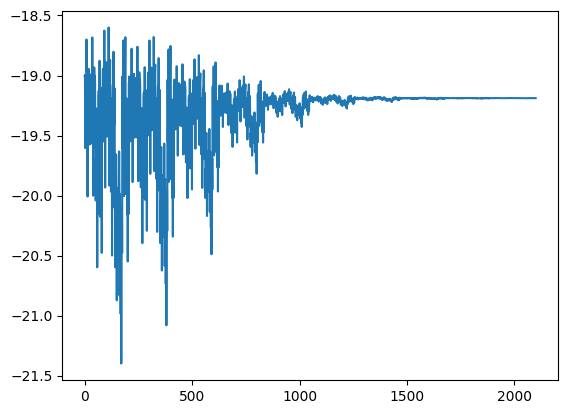

In [15]:
##using validation scores
import numpy as np
import matplotlib.pyplot as plt
plt.plot(np.arange(len(losses)),np.array(losses))

In [16]:
index = np.nanargmax(np.array(validation_Scores))
index,validation_Scores[index],valparams[index]

(167, 0.8400000000000001, (2, 2, 0, 2, 0.01))

In [17]:
##training on entire dataset
lamda = valparams[index][4]
powert1 = valparams[index][0]
powert2 = valparams[index][1]
powert3 = valparams[index][2]
powert4 = valparams[index][3]
xes = transform_data(x_train,powert1,powert2,powert3,powert4)
biased_xes = np.c_[np.ones(len(xes)),xes]
n = len(xes)
y_tr = np.array(y_train).ravel()
betas = np.zeros(xes.shape[1]+1)
for epoch in range(0,20000):
    xbetas = np.matmul(biased_xes,betas)
    gradient = np.matmul(biased_xes.transpose(),sigmoid(xbetas)-y_tr)
    identity_mat = np.identity(len(betas))
    dmat = np.identity(len(betas))
    dmat[0][0] = 0
    betas = np.matmul(identity_mat-alpha*lamda*dmat,betas) - 1/n*alpha*gradient
##train accuracy
xbetas = np.matmul(biased_xes,betas)
predictions = sigmoid(xbetas)
actuals = y_tr
score = roc_auc_score(actuals,predictions)
print(f"Training Score: {score}")
train_Scores.append(score)


Training Score: 0.8658008658008658


In [18]:
##test accuracy
y_t = np.array(y_test).ravel()
xes = transform_data(x_test,powert1,powert2,powert3,powert4)
biased_xes = np.c_[np.ones(len(xes)),xes]
xbetas = np.matmul(biased_xes,betas)
predictions = sigmoid(xbetas)
actuals = y_t
score = roc_auc_score(actuals,predictions)
print(f"Test Score: {score}")

Test Score: 0.9027777777777778


In [19]:
betas

array([ 0.50679502, -0.61756192, -0.39025632, -0.39025632,  0.15215941,
        0.19542084])

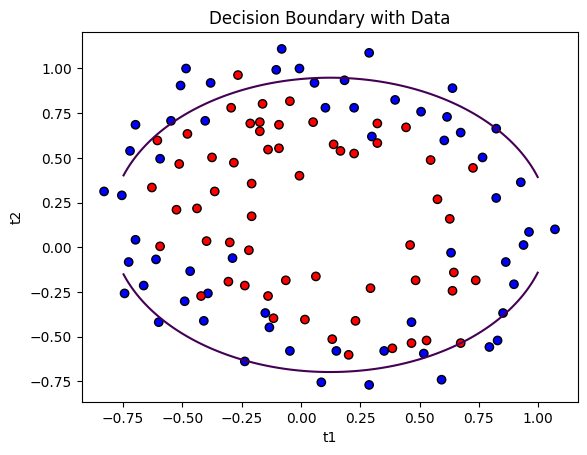

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# load data

t1_data = df["t1"].values
t2_data = df["t2"].values
y = df["target"].values

# betas
b0, b1, b2, b3, b4, b5 = betas

# grid
t1_vals = np.linspace(-0.75, 1, 200)
t2_vals = np.linspace(-0.75, 1, 200)

T1, T2 = np.meshgrid(t1_vals, t2_vals)

# compute z
Z = b0 + b1*T1**powert1 + b2*T2**powert2 + b3*(T1**powert3)*(T2**powert4) + b4*T1 + b5*T2

# plot decision boundary
plt.contour(T1, T2, Z, levels=[0])

# plot points
plt.scatter(t1_data, t2_data, c=y, cmap='bwr', edgecolors='k')

plt.xlabel("t1")
plt.ylabel("t2")
plt.title("Decision Boundary with Data")
plt.show()